## Data Exploration


Dieses Skript ist die Preperation und Exploration der Datasets von DocILE und VRDU zur Extraktiono und Operationalisierung von L1 - L3.

Um den Skript auszuführen müssen die Daten aus den Quellrepositories ausgeführt werden:
- ./scripts/download_dataset_docile.sh
- ./scripts/download_dataset_vrdu.sh

(Das Ergebnis des Skripts sind die aufbereiteten daten unter "data/pdfs" und "data/processed" mit den entsprechenden corpus l1 - l3 dateien.)

### VRDU: Registration Form

In [62]:
import json
import pandas as pd 

In [63]:
df_registration_form =pd.read_json("../data/vrdu/registration-form/main/dataset.jsonl", lines=True)

df_registration_form.head(5)

,filename,file_path,ocr,annotations
0,19410222_DLA Piper US LLP_Amendment_Amendment.pdf,./pdfs/19410222_DLA Piper US LLP_Amendment_Ame...,{'text': 'i OMB NO. 1124-0003 U.S. Department ...,"[[registration_num, [['3712\n', [0, 0.46376812..."
1,"19620326_Austrian Tourist Office, Inc._Amendme...","./pdfs/19620326_Austrian Tourist Office, Inc._...",{'text': 'Budget Bureau No. 42 9226.3 proval E...,"[[registration_num, [['495\n', [0, 0.83961117,..."
2,19630401_Arab Information Center_Amendment_Ame...,./pdfs/19630401_Arab Information Center_Amendm...,{'text': 'App Budge Bureau No. 226.3 Expires J...,"[[registration_num, [['876\n', [0, 0.809428270..."
3,19630601_Arab Information Center_Amendment_Ame...,./pdfs/19630601_Arab Information Center_Amendm...,{'text': 'Feet Bureau No. 43-P226.3 val Expire...,"[[registration_num, [['876\n', [0, 0.79343861,..."
4,19630701_KOTRA_Amendment_Amendment.pdf,./pdfs/19630701_KOTRA_Amendment_Amendment.pdf,{'text': 'Budget Burd Jo. 43-R227.1 Approval E...,"[[registration_num, [['16/9\n', [0, 0.78614825..."


In [64]:
df_registration_form.describe()

,filename,file_path,ocr,annotations
count,1915,1915,1915,1915
unique,1915,1915,1915,1915
top,19410222_DLA Piper US LLP_Amendment_Amendment.pdf,./pdfs/19410222_DLA Piper US LLP_Amendment_Ame...,{'text': 'i OMB NO. 1124-0003 U.S. Department ...,"[[registration_num, [['3712\n', [0, 0.46376812..."
freq,1,1,1,1


In [65]:
df_registration_form.ocr[0]

{'text': "i\nOMB NO. 1124-0003\nU.S. Department of Justice\nWashington, DC 20530\nAmendment to Registration Statement\nPursuant to the Foreign Agents Registration Act of 1938, as amended\nPrivacy Act Statement. The filing of this document is required by the Foreign Agents Registration Act of 1938, as amended, 22 U.S.C. § 611 et seq., for the\npurposes of registration under the Act and public disclosure. Provision of the information requested is mandatory, and failure to provide this information is\nsubject to the penalty and enforcement provisions established in Section 8 of the Act. Every registration statement, short form registration statement,\nsupplemental statement, exhibit, amendment, copy of informational materials or other document or information filed with the Attorney General under this\nAct is a public record open to public examination, inspection and copying during the posted business hours of the Registration Unit in Washington, DC.\nStatements are also available online a

In [66]:
def parse_vrdu_annotations(annotations_list):
    """
    Entpackt die verschachtelte VRDU-Annotations-Liste in ein flaches Dictionary.
    Fängt flache Strings, hierarchische Werte UND hierarchische Keys sicher ab.
    """
    extracted_data = {}
    
    # Sicherstellen, dass es überhaupt eine Liste ist
    if not isinstance(annotations_list, list):
        return extracted_data
        
    for entity in annotations_list:
        if len(entity) >= 2:
            raw_key = entity[0]
            
            if isinstance(raw_key, list):
                entity_name = "___".join([str(k) for k in raw_key])
            else:
                entity_name = str(raw_key)
                
            entity_values = entity[1]
            
            # Prüfen, ob Werte vorhanden sind
            if isinstance(entity_values, list) and len(entity_values) > 0:
                first_val = entity_values[0][0]
                
                if isinstance(first_val, str):
                    extracted_data[entity_name] = first_val.strip()
                    
                elif isinstance(first_val, list):
                    extracted_data[entity_name] = f"<HIERARCHISCHE_LISTE_MIT_{len(first_val)}_ELEMENTEN>"
                    
                else:
                    extracted_data[entity_name] = str(first_val)
                    
    return extracted_data

def evaluate_complexity(df, dataset_name):
    """
    Berechnet die Metriken zum empirischen Beweis der Dokumentenkomplexität (L2 vs L3).
    """
    print(f"--- Analyse: {dataset_name} ---")
    
    df['parsed_annotations'] = df['annotations'].apply(parse_vrdu_annotations)
    
    # Entitätsdichte berechnen 
    df['entity_count'] = df['parsed_annotations'].apply(len)
    avg_entities = df['entity_count'].mean()
    
    # Prüfung auf hierarchische Felder
    has_line_items = any(
        df['parsed_annotations'].apply(
            lambda x: any(str(v).startswith("<HIERARCHISCHE") for v in x.values()) or 
                      any("___" in str(k) for k in x.keys())
        )
    )
    
    print(f"Durchschnittliche Entitätsdichte: {avg_entities:.2f} Felder pro Dokument")
    print(f"Enthält hierarchische Tabellendaten (Line-Items): {'Ja (-> L3 Charakteristik)' if has_line_items else 'Nein (-> L1/L2 Charakteristik)'}")
    
    # Beispiel-Ausdruck des ersten Dokuments
    print("\nBeispiel-Extraktion (Ground Truth des 1. Dokuments):")
    print(json.dumps(df['parsed_annotations'].iloc[0], indent=2, ensure_ascii=False))
    print("\n")
    
    return df

df_registration_form = evaluate_complexity(df_registration_form, "Registration Forms (L2 Kandidat)")

--- Analyse: Registration Forms (L2 Kandidat) ---
Durchschnittliche Entitätsdichte: 4.61 Felder pro Dokument
Enthält hierarchische Tabellendaten (Line-Items): Nein (-> L1/L2 Charakteristik)

Beispiel-Extraktion (Ground Truth des 1. Dokuments):
{
  "registration_num": "3712",
  "registrant_name": "DLA Piper US LLP",
  "file_date": "July 16, 2008"
}




### VRDU: Ad-Buy-Form

In [67]:
import pandas as pd 

df_ad_buy_form =pd.read_json("../data/vrdu/ad-buy-form/main/dataset.jsonl", lines=True)

df_ad_buy_form.head(5)

,filename,file_path,ocr,annotations
0,00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,./pdfs/00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,{'text': 'Page 1 of 2 INVOICE FOX Remit Addres...,"[[property, [['KMSP\n', [0, 0.14883721, 0.0662..."
1,00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,./pdfs/00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,{'text': 'Page 1 of 1 INVOICE DUE ATE 2436316-...,"[[property, [['WXXA\n', [0, 0.14763948, 0.0677..."
2,00c3353e-a25f-574a-a9db-39a41579895a.pdf,./pdfs/00c3353e-a25f-574a-a9db-39a41579895a.pdf,{'text': 'Print Date 02/28/20 14:21:20 Page 1 ...,"[[contract_num, [['14086\n', [0, 0.27917981000..."
3,01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,./pdfs/01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,{'text': 'Page 1 of 4 INVOICE Advertiser 4 Rem...,"[[property, [['KCNC-TV\n', [0, 0.14883721, 0.0..."
4,0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,./pdfs/0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,{'text': 'Contract # Date Entered Schedule Dat...,"[[contract_num, [['575746\n', [0, 0.3472609200..."


In [68]:
df_ad_buy_form = evaluate_complexity(df_ad_buy_form, "Ad-Buy Forms (L3 Kandidat)")

--- Analyse: Ad-Buy Forms (L3 Kandidat) ---
Durchschnittliche Entitätsdichte: 10.30 Felder pro Dokument
Enthält hierarchische Tabellendaten (Line-Items): Ja (-> L3 Charakteristik)

Beispiel-Extraktion (Ground Truth des 1. Dokuments):
{
  "property": "KMSP",
  "tv_address": "4614 Collection Center Drive\nChicago, IL 60693",
  "advertiser": "Michael Bloomberg 2020, Inc",
  "product": "MIKE BLOOMBERG 2020 INC",
  "contract_num": "950658",
  "flight_to": "03/29/20",
  "flight_from": "12/30/19",
  "gross_amount": "$5,625.00",
  "channel___program_desc___program_start_date___program_end_date": "<HIERARCHISCHE_LISTE_MIT_3_ELEMENTEN>",
  "channel___program_desc": "<HIERARCHISCHE_LISTE_MIT_3_ELEMENTEN>"
}




### Docile

In [69]:
with open("../data/docile/annotations/0a1bf0ac3db840e1be10e064.json", "r") as f:
    data = json.load(f)

# Gezielt den Teil in einen DataFrame umwandeln, der dich interessiert
df_fields = pd.json_normalize(data, record_path=['field_extractions'])

df_line_items = pd.json_normalize(data, record_path=['line_item_extractions'])

print(df_fields.head())

                                                bbox  \
0  [0.6491683867555995, 0.09200664549297072, 0.72...   
1  [0.7442520598420361, 0.17343781449249657, 0.81...   
2  [0.5967741935483871, 0.8266832917705735, 0.703...   
3  [0.09576772828849729, 0.1729090406678243, 0.30...   
4  [0.09713583869261867, 0.17238026684315205, 0.3...   

                  fieldtype  page  \
0               document_id     0   
1               vendor_name     0   
2               vendor_name     0   
3     customer_billing_name     0   
4  customer_billing_address     0   

                                                text  
0                                         1408014338  
1                                            WGTY-FM  
2                                     agency(and MBS  
3    MAIN STREET MEDIA GROUP\nSENATE LEADERSHIP FUND  
4  MAIN STREET MEDIA GROUP\nSENATE LEADERSHIP FUN...  


In [70]:
df_ocr = pd.read_json("../data/docile/ocr/0a1bf0ac3db840e1be10e064.json", lines=True)

df_ocr.pages[0]

[{'page_idx': 0,
  'dimensions': [1684, 1302],
  'orientation': {'value': None, 'confidence': None},
  'language': {'value': None, 'confidence': None},
  'blocks': [{'geometry': [[0.2763671875, 0.076171875],
     [0.4521484375, 0.130859375]],
    'lines': [{'geometry': [[0.2763671875, 0.076171875],
       [0.4521484375, 0.09765625]],
      'words': [{'value': 'Broadcast',
        'confidence': 0.9957334399223321,
        'geometry': [[0.2763671875, 0.076171875], [0.4521484375, 0.09765625]],
        'snapped_geometry': [[0.276395798783858, 0.076100897819581],
         [0.45163073521282404, 0.097477554510474]]}]},
     {'geometry': [[0.27734375, 0.109375], [0.42578125, 0.130859375]],
      'words': [{'value': 'Contract',
        'confidence': 0.9987962245941161,
        'geometry': [[0.27734375, 0.109375], [0.42578125, 0.130859375]],
        'snapped_geometry': [[0.27750138197899304, 0.10944848225737401],
         [0.42399115533443804, 0.12997007268063202]]}]}],
    'artefacts': []},
   

In [71]:
import os
import glob
import json
import pandas as pd

def evaluate_docile_complexity(annotations_dir):
    print("--- Analyse: Docile (L3 Kandidat) ---")
    
    metrics = []
    # Alle JSON-Dateien im Docile Annotations-Ordner finden
    file_paths = glob.glob(os.path.join(annotations_dir, "*.json"))
    
    if not file_paths:
        print("Keine JSON-Dateien im angegebenen Pfad gefunden.")
        return
        
    for file in file_paths:
        with open(file, "r") as f:
            data = json.load(f)
            
        # 1. Kopfdaten (z.B. vendor_name, document_id, amount_due)
        field_extractions = data.get("field_extractions", [])
        num_fields = len(field_extractions)
        
        # 2. Tabellendaten (Line Items)
        line_item_extractions = data.get("line_item_extractions", [])
        num_line_item_cells = len(line_item_extractions)
        
        # Finde heraus, wie viele echte Tabellenzeilen existieren (anhand der line_item_id)
        unique_rows = len(set(item.get("line_item_id") for item in line_item_extractions))
        
        metrics.append({
            "filename": os.path.basename(file),
            "num_fields": num_fields,
            "num_line_item_cells": num_line_item_cells,
            "num_table_rows": unique_rows
        })
        
    df_metrics = pd.DataFrame(metrics)
    
    # Metriken berechnen
    avg_fields = df_metrics['num_fields'].mean()
    avg_table_rows = df_metrics['num_table_rows'].mean()
    docs_with_tables = (df_metrics['num_table_rows'] > 0).mean() * 100
    
    print(f"Analysierte Dokumente: {len(df_metrics)}")
    print(f"Durchschnittliche Entitätsdichte (Kopfdaten): {avg_fields:.2f} Felder pro Dokument")
    print(f"Durchschnittliche Tabellenzeilen: {avg_table_rows:.2f} Zeilen pro Dokument")
    print(f"Enthält hierarchische Tabellendaten (Line-Items): Ja ({docs_with_tables:.1f}% der Dokumente)")
    
    return df_metrics

# Pfad anpassen, falls nötig
df_docile_metrics = evaluate_docile_complexity("../data/docile/annotations/")
df_docile_metrics.head()

--- Analyse: Docile (L3 Kandidat) ---
Analysierte Dokumente: 5680
Durchschnittliche Entitätsdichte (Kopfdaten): 12.59 Felder pro Dokument
Durchschnittliche Tabellenzeilen: 6.81 Zeilen pro Dokument
Enthält hierarchische Tabellendaten (Line-Items): Ja (93.8% der Dokumente)


,filename,num_fields,num_line_item_cells,num_table_rows
0,33bd367db9a4439887f600aa.json,11,44,11
1,183b1a67b9a9413583eb2dcf.json,11,2,1
2,812d1b205fdd41b9b86c8056.json,7,3,1
3,8538e1e4800643c493e119d9.json,22,3,1
4,03632555cc3b4e71b91b793d.json,9,54,9


# Aufteilung von L1 - L3

In [72]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import Document

print(Document.__annotations__)

{'id': <class 'str'>, 'complexity': <class 'str'>, 'content': <class 'str'>, 'metadata': <class 'dict'>}


Ein Dokument für das Experiment wird in folgender Struktur in einem jsonl eingerichtet:

id -> uuid

complexity -> L1, L2, L3

content -> roher Text oder OCR output

metadaten -> dateiname, dateipfad, dateityp

```json
{
    'id': <class 'str'>, 
    'complexity': <class 'str'>, 
    'content': <class 'str'>, 
    'metadata': <class 'dict'>
}
```

### Operationalisierung von L1

In [73]:
with open(
    "../data/vrdu/registration-form/few_shot-splits/FARA-lv1-single_Amendment-train_200-test_300-valid_100-SD_0.json",
    "r"   
) as f:
    l1 = json.load(f)

l1 = l1["train"] + l1["test"] + l1["valid"]

print(l1[0:10])
print(len(l1))

['20170606_Sonoran Policy Group, LLC_Amendment_Amendment.pdf', '20170418_Husch Blackwell, LLP_Amendment_Amendment.pdf', '20060817_MSLGROUP Americas, Inc._Amendment_Amendment.pdf', '19910801_British Virgin Islands Tourist Board_Amendment_Amendment.pdf', '20170927_Kingery, Samet _ Sorini, PLLC_Amendment_Amendment.pdf', '20150601_Cassidy _ Associates, Inc._Amendment_Amendment.pdf', '20080623_Sorini, Samet _ Associates, LLC_Amendment_Amendment.pdf', '20100812_Hill and Knowlton Strategies, LLC_Amendment_Amendment.pdf', '19790601_Quebec Government Office_Amendment_Amendment.pdf', '20141105_Squire Patton Boggs, LLP_Amendment_Amendment.pdf']
600


In [74]:
if len(l1) != len(set(l1)):
    print(f"Original: {len(l1)}, Without dublicates: {len(set(l1))}")
else:
    print("No dublicates")

No dublicates


In [75]:
import json
import uuid
import shutil
from pathlib import Path
import pandas as pd

def export_vrdu_split(
    df: pd.DataFrame,
    split_filenames: list,
    complexity_label: str,  
    source_base_dir: Path,
    target_pdf_dir: Path,
    target_jsonl_path: Path,
):
    target_pdf_dir.mkdir(parents=True, exist_ok=True)
    target_jsonl_path.parent.mkdir(parents=True, exist_ok=True)

    documents = []
    missing_files = 0
    not_in_split_count = 0

    for index, row in df.iterrows():
        file_name = row["filename"]

        if file_name not in split_filenames:
            not_in_split_count += 1
            continue

        relative_pdf_path = row["file_path"].replace("./", "")
        source_pdf_path = source_base_dir / relative_pdf_path

        target_pdf_path = target_pdf_dir / file_name

        if source_pdf_path.exists():
            shutil.copy2(source_pdf_path, target_pdf_path)
        else:
            print(
                f"WARNUNG: Quelldatei nicht gefunden übersprungen -> {source_pdf_path}"
            )
            missing_files += 1
            continue

        content_text = ""
        if isinstance(row["ocr"], dict) and "text" in row["ocr"]:
            content_text = row["ocr"]["text"]

        gt = parse_vrdu_annotations(row["annotations"])

        doc = {
            "id": uuid.uuid4().hex,
            "complexity": complexity_label,
            "metadata": {
                "source": "VRDU Registration Form",
                "document_name": file_name,
                "raw_file_path": str(target_pdf_path),
                "original_file_path": row["file_path"],
            },
            "content": content_text,
            "ground_truth": gt,
        }
        documents.append(doc)

    with open(target_jsonl_path, "w", encoding="utf-8") as f:
        for doc in documents:
            f.write(json.dumps(doc, ensure_ascii=False) + "\n")

    print(
        f"Abgeschlossen! {len(documents)} Dokumente für {complexity_label} erfolgreich verarbeitet."
    )
    print(
        f"{not_in_split_count} Dokumente wurden ignoriert (nicht in der übergebenen Liste)."
    )

    if missing_files > 0:
        print(
            f"{missing_files} Dokumente wurden übersprungen (PDF fehlte auf der Festplatte)!"
        )

    return documents


In [76]:

documents_l1_full = export_vrdu_split(
    df=df_registration_form,
    split_filenames=l1,
    complexity_label="L1",
    source_base_dir=Path("../data/vrdu/registration-form/main/"),
    target_pdf_dir=Path("../data/pdfs/l1"),
    target_jsonl_path=Path("../data/processed/corpus_l1_full.jsonl"),
)

Abgeschlossen! 600 Dokumente für L1 erfolgreich verarbeitet.
1315 Dokumente wurden ignoriert (nicht in der übergebenen Liste).


In [77]:
df_l1_registration_form = pd.read_json("../data/processed/corpus_l1_full.jsonl", lines=True)
df_l1_registration_form.head()

,id,complexity,metadata,content,ground_truth
0,1cf9836aef7f4dfe8ddd4376f68cb398,L1,"{'source': 'VRDU Registration Form', 'document...",Budget Bureau No. 42 9226.3\nproval Expires\ny...,"{'registration_num': '495', 'registrant_name':..."
1,9b10093d0875477da7c40b999983ec7f,L1,"{'source': 'VRDU Registration Form', 'document...","App\nBudge Bureau No. 226.3\nExpires J\ny 31, ...","{'registration_num': '876', 'registrant_name':..."
2,3ef85e390b954a6587a6bcf2c5bfb903,L1,"{'source': 'VRDU Registration Form', 'document...","Feet Bureau No. 43-P226.3\nval Expires Ja 31, ...","{'registration_num': '876', 'registrant_name':..."
3,b8109df649d14dc588c0a165b32932bd,L1,"{'source': 'VRDU Registration Form', 'document...",Budget Burd Jo. 43-R227.1\nApproval Expires Ja...,"{'registration_num': '16/9', 'registrant_name'..."
4,d6ab6f3bc0fe4945b5578656d447053d,L1,"{'source': 'VRDU Registration Form', 'document...","get Bureau No. 43-R 3\noval Expires Janual, 19...",{'registrant_name': 'AUSTRALIAN NATIONAL TRAVE...


In [78]:
df_l1_registration_form.ground_truth.map(lambda x: list(x.keys()) if isinstance(x, dict) else [])

0      [registration_num, registrant_name, foreign_pr...
1      [registration_num, registrant_name, foreign_pr...
2      [registration_num, registrant_name, foreign_pr...
3      [registration_num, registrant_name, foreign_pr...
4      [registrant_name, foreign_principle_name, sign...
                             ...                        
595    [registration_num, registrant_name, file_date,...
596    [registrant_name, registration_num, file_date,...
597    [registration_num, registrant_name, file_date,...
598    [registration_num, registrant_name, file_date,...
599    [registration_num, registrant_name, file_date,...
Name: ground_truth, Length: 600, dtype: object

### Operationalisierung von L2

In [79]:
with open(
    "../data/vrdu/registration-form/few_shot-splits/FARA-lv2-mixed_template-train_200-test_300-valid_100-SD_2.json",
    "r",
) as f:
    l2 = json.load(f)

l2 = l2["train"] + l2["test"] + l2["valid"]

print(l2[0:10])
print(len(l2))

['20110912_BLJ Worldwide LTD_Smrikarov, Marc Philip George_Short-Form.pdf', '20170222_Nickles Group, LLC_Amendment_Amendment.pdf', '20161229_Crowell _ Moring International, Ltd._Bacigalupo, Patricia Wu_Short-Form.pdf', '20171010_MSLGROUP Americas, Inc._Harper, Clinton L._Short-Form.pdf', '20160208_Ketchum Inc. NY_Mann, Nicole_Short-Form.pdf', '19920301_Kobe Trade Information Office_Dissemination Report_Dissemination Report.pdf', '19920801_Scottish Enterprise_Dissemination Report_Dissemination Report.pdf', '20150218_Quebec Government Office_Fallecker, Stephane_Short-Form.pdf', '20180112_RunSwitch PR, LLC_Carnahan, Kaylee_Short-Form.pdf', '20070302_Glover Park Group, LLC_Amendment_Amendment.pdf']
600


In [80]:
if len(l2) != len(set(l2)):
    print(f"Original: {len(l2)}, Without dublicates: {len(set(l2))}")
else:
    print("No dublicates")

No dublicates


Überschneidung zwischen L1 und L2 für unser Experiment disjunktieren. Da kein Data Leakage zwischen den beiden Bedingungen stattfinden soll.

In [81]:
dublicates_in_l1_and_l2 = len(df_registration_form["filename"].isin(l1))

dublicates_in_l1_and_l2

1915

In [82]:
df_registration_form_without_l1 = df_registration_form[~df_registration_form['filename'].isin(l1)]

In [83]:
documents_l2_full = export_vrdu_split(
    df=df_registration_form_without_l1,
    split_filenames=l2,
    complexity_label="L2",
    source_base_dir=Path("../data/vrdu/registration-form/main/"),
    target_pdf_dir=Path("../data/pdfs/l2"),
    target_jsonl_path=Path("../data/processed/corpus_l2_full.jsonl"),
)

Abgeschlossen! 423 Dokumente für L2 erfolgreich verarbeitet.
892 Dokumente wurden ignoriert (nicht in der übergebenen Liste).


In [84]:
df_l2_registration_form = pd.read_json(
    "../data/processed/corpus_l2_full.jsonl", lines=True
)
df_l2_registration_form.head()

,id,complexity,metadata,content,ground_truth
0,c5a9e721b924466088ee27bb04426679,L2,"{'source': 'VRDU Registration Form', 'document...",UNITED STATES DEPARTMENT OF JUSTICE\nWASHINGTO...,"{'registrant_name': 'Quebec Government House',..."
1,24c5190bfa86406f8d52cf56b749b43c,L2,"{'source': 'VRDU Registration Form', 'document...","NY 226\nApproval Expires Oct. 31, 1981\nUNITED...","{'registration_num': '3354', 'registrant_name'..."
2,13e4f4b944354e4296d77784710b5e41,L2,"{'source': 'VRDU Registration Form', 'document...",OMB No. 1105-0004\nU.S.-Department of Justice\...,"{'registration_num': '1750', 'registrant_name'..."
3,0a5c5f24ebdf4018b509d81f7e7b3c35,L2,"{'source': 'VRDU Registration Form', 'document...","U.S. Department of Justice\nWashington, D.C. 2...",{'registrant_name': 'Singapore Economic Develo...
4,c93eee0c39ab473e979dd8a1b06fdb69,L2,"{'source': 'VRDU Registration Form', 'document...",OMB No. 1105-0004\nU.S. Department of Junce\nW...,"{'registrant_name': 'Arnold & Porter', 'regist..."


### Check Data Leakage

Datenüberschneidung zwischen dem L1 und L2 Datensatz festellen:

In [85]:
l1_docs = set(df_l1_registration_form['metadata'].apply(lambda x: x.get('document_name')))
l2_docs = set(df_l2_registration_form['metadata'].apply(lambda x: x.get('document_name')))

overlap = l1_docs.intersection(l2_docs)

if len(overlap) == 0:
    print("Keine Überschneidungen zwischen L1 und L2. Kein Data Leakage.")
else:
    print(f"{len(overlap)} Dokumente überschneiden sich!")
    print(f"Beispiele für Überschneidungen: {list(overlap)[:5]}")

Keine Überschneidungen zwischen L1 und L2. Kein Data Leakage.


In [86]:
df_l1_registration_form['text_length'] = df_l1_registration_form['content'].apply(len)
df_l2_registration_form['text_length'] = df_l2_registration_form['content'].apply(len)

l1_mean = df_l1_registration_form['text_length'].mean()
l1_std = df_l1_registration_form['text_length'].std()

l2_mean = df_l2_registration_form['text_length'].mean()
l2_std = df_l2_registration_form['text_length'].std()

print("L1 (Geringe Komplexität - Single Template):")
print(f" - Durchschnittliche Textlänge: {l1_mean:.2f} Zeichen")
print(f" - Standardabweichung:          {l1_std:.2f} Zeichen")

print("\nL2 (Moderate Komplexität - Mixed Template):")
print(f" - Durchschnittliche Textlänge: {l2_mean:.2f} Zeichen")
print(f" - Standardabweichung:          {l2_std:.2f} Zeichen")


L1 (Geringe Komplexität - Single Template):
 - Durchschnittliche Textlänge: 4425.57 Zeichen
 - Standardabweichung:          1116.71 Zeichen

L2 (Moderate Komplexität - Mixed Template):
 - Durchschnittliche Textlänge: 5603.34 Zeichen
 - Standardabweichung:          1541.77 Zeichen


### Operationalisierung von L3

Für L3 wird eine Stichprobe aus DOCILE und VRDU - ad-buy-form verwendet.

In [87]:
df_ad_buy_form = pd.read_json("../data/vrdu/ad-buy-form/main/dataset.jsonl", lines=True)

df_ad_buy_form.head(5)

,filename,file_path,ocr,annotations
0,00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,./pdfs/00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,{'text': 'Page 1 of 2 INVOICE FOX Remit Addres...,"[[property, [['KMSP\n', [0, 0.14883721, 0.0662..."
1,00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,./pdfs/00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,{'text': 'Page 1 of 1 INVOICE DUE ATE 2436316-...,"[[property, [['WXXA\n', [0, 0.14763948, 0.0677..."
2,00c3353e-a25f-574a-a9db-39a41579895a.pdf,./pdfs/00c3353e-a25f-574a-a9db-39a41579895a.pdf,{'text': 'Print Date 02/28/20 14:21:20 Page 1 ...,"[[contract_num, [['14086\n', [0, 0.27917981000..."
3,01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,./pdfs/01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,{'text': 'Page 1 of 4 INVOICE Advertiser 4 Rem...,"[[property, [['KCNC-TV\n', [0, 0.14883721, 0.0..."
4,0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,./pdfs/0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,{'text': 'Contract # Date Entered Schedule Dat...,"[[contract_num, [['575746\n', [0, 0.3472609200..."


In [88]:
with open(
    "../data/vrdu/ad-buy-form/few_shot-splits/DeepForm-unk_template-train_200-test_159-valid_100-SD_0.json",
    "r",
) as f:
    l3 = json.load(f)

l3 = l3["train"] + l3["test"] + l3["valid"]
print(l3[0:10])
print(len(l3))

['a65d507b-a4ca-5234-f0f0-90ba2a105c6a.pdf', '8012f928-879f-d133-d539-ac40deb9ca5d.pdf', 'e87504ee-8fcc-951c-0652-0ff54129fa64.pdf', '4add49ba-5a10-92b4-36d4-999b09a9b27a.pdf', 'bc21c8e3-8a42-5d9e-b5a4-28e79aae6c68.pdf', '71810401-8e3b-ff82-5d7d-ba86dae4b684.pdf', '57342711-af76-eec9-60b9-f064be838373.pdf', 'da77aaa0-2540-4aa6-8f25-19be10a1900b.pdf', '161648f7-00b2-bf14-373b-83436d07e037.pdf', '99231788-a487-404b-aeba-3ea9dd2fe3b6.pdf']
459


In [89]:
ad_buy_documents = export_vrdu_split(
    df=df_ad_buy_form,
    split_filenames=l3,
    complexity_label="L3",
    source_base_dir=Path("../data/vrdu/ad-buy-form/main/"),
    target_pdf_dir=Path("../data/pdfs/l3"),
    target_jsonl_path=Path("../data/processed/corpus_l3_full.jsonl"),
)

Abgeschlossen! 459 Dokumente für L3 erfolgreich verarbeitet.
182 Dokumente wurden ignoriert (nicht in der übergebenen Liste).


### DocILE zu L3 hinzufügen

In [90]:
n_documents_l3 = len(ad_buy_documents)

with open("../data/docile/train.json", "r") as f:
    docile_names = json.load(f)

documents = []

for i in range(n_documents_l3):
    with open(f"../data/docile/annotations/{docile_names[i]}.json", "r") as f:
        annotations = json.load(f)

    with open(f"../data/docile/ocr/{docile_names[i]}.json", "r") as f:
        ocr = json.load(f)

    document = {
        "id": uuid.uuid4().hex,
        "complexity": "L3",
        "metadata": {
            "source": "DocILE",
            "document_name": docile_names[i],
            "raw_file_path": f"../data/docile/pdfs/{docile_names[i]}.pdf",
        },
        "content": ocr,
        "ground_truth": annotations,
    }
    documents.append(document)


with open("../data/processed/corpus_l3_full.jsonl", "a", encoding="utf-8") as f:
    for doc in documents:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n")

print(
    f"{len(documents)} DocILE-Dokumente an 'corpus_l3_full.jsonl' angehängt!"
)

459 DocILE-Dokumente an 'corpus_l3_full.jsonl' angehängt!


## Stichprobe ziehen

Pro corpus werden 100 Dokumente randomisiert als 

In [92]:
def create_sample_dataset(input_jsonl, output_jsonl, pdf_dir=None, n_samples=100):
    """Zieht n_samples, speichert final und löscht ungenutzte PDFs (falls pdf_dir angegeben)."""
    print(f"\n--- Verarbeite {input_jsonl} ---")

    df = pd.read_json(input_jsonl, lines=True)

    if len(df) > n_samples:
        df = df.sample(n=n_samples, random_state=42)

    print(f"Stichprobe gezogen: {len(df)} Dokumente.")
    df.to_json(output_jsonl, orient="records", lines=True, force_ascii=False)

    # PDFs aufräumen (NUR wenn ein Pfad übergeben wurde, um Originaldaten zu schützen!)
    if pdf_dir:
        keep_pdf_names = set(df["metadata"].apply(lambda x: x.get("document_name")))
        deleted_count = 0
        for pdf_file in Path(pdf_dir).glob("*.pdf"):
            if pdf_file.name not in keep_pdf_names:
                pdf_file.unlink()
                deleted_count += 1
        print(f"Cleanup: {deleted_count} nicht benötigte PDFs aus {pdf_dir} gelöscht.")

    return df

In [93]:
l1_sample_path = "../data/processed/corpus_l1_experiment.jsonl"
l2_sample_path = "../data/processed/corpus_l2_experiment.jsonl"
l3_sample_path = "../data/processed/corpus_l3_experiment.jsonl"

# L1 und L2 vorbereiten
df_l1 = create_sample_dataset(
    "../data/processed/corpus_l1_full.jsonl", l1_sample_path, "../data/pdfs/l1", 100
)
df_l2 = create_sample_dataset(
    "../data/processed/corpus_l2_full.jsonl", l2_sample_path, "../data/pdfs/l2", 100
)

# L3 Stratified Sampling 50/50
df_l3_full = pd.read_json("../data/processed/corpus_l3_full.jsonl", lines=True)

# Trennen nach Quelle
mask_docile = df_l3_full["metadata"].apply(lambda x: x.get("source")) == "DocILE"
df_l3_docile = df_l3_full[mask_docile]
df_l3_adbuy = df_l3_full[~mask_docile]

sample_docile = df_l3_docile.sample(n=50, random_state=42)
sample_adbuy = df_l3_adbuy.sample(n=50, random_state=42)

df_l3_final = (
    pd.concat([sample_docile, sample_adbuy])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(
    f"L3 Stichprobe: {len(sample_docile)} DocILE + {len(sample_adbuy)} Ad-Buy = {len(df_l3_final)} Dokumente."
)

# L3 Speichern
df_l3_final.to_json(l3_sample_path, orient="records", lines=True, force_ascii=False)


--- Verarbeite ../data/processed/corpus_l1_full.jsonl ---
Stichprobe gezogen: 100 Dokumente.
Cleanup: 500 nicht benötigte PDFs aus ../data/pdfs/l1 gelöscht.

--- Verarbeite ../data/processed/corpus_l2_full.jsonl ---
Stichprobe gezogen: 100 Dokumente.
Cleanup: 323 nicht benötigte PDFs aus ../data/pdfs/l2 gelöscht.
L3 Stichprobe: 50 DocILE + 50 Ad-Buy = 100 Dokumente.


# Further Data Exploration

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_l1 = pd.read_json("../data/processed/corpus_l1_experiment.jsonl", lines=True)
df_l2 = pd.read_json("../data/processed/corpus_l2_experiment.jsonl", lines=True)
df_l3 = pd.read_json("../data/processed/corpus_l3_experiment.jsonl", lines=True)


def count_line_items(gt):
    if not isinstance(gt, dict):
        return 0
    # Prüfe verschiedene gängige Keys für Tabellenzeilen
    for key in ["line_items", "items", "positions"]:
        if key in gt and isinstance(gt[key], list):
            return len(gt[key])
    return 0


def count_flat_fields(gt):
    if not isinstance(gt, dict):
        return 0
    # Zählt alles, was keine Liste oder Dict ist (Kopfdaten)
    return len([v for k, v in gt.items() if not isinstance(v, (list, dict))])


def count_flat_fields(gt):
    """Zählt die flachen Kopfdaten-Felder."""
    if isinstance(gt, dict):
        return len([k for k in gt.keys() if k != "line_items"])
    return 0


for df, label in zip(
    [df_l1, df_l2, df_l3],
    ["L1 (Single Template)", "L2 (Mixed Template)", "L3 (Unseen + Hierarchisch)"],
):
    df["Level"] = label
    df["text_length"] = df["content"].fillna("").apply(len)
    df["flat_fields_count"] = df["ground_truth"].apply(count_flat_fields)
    df["line_items_count"] = df["ground_truth"].apply(count_line_items)
    df["is_hierarchical"] = df["line_items_count"] > 0

df_all = pd.concat([df_l1, df_l2, df_l3], ignore_index=True)

print(" Darstellung der Komplexitätsstufen \n")
stats = (
    df_all.groupby("Level")
    .agg(
        Dokumente=("id", "count"),
        Ø_Textlänge=("text_length", "mean"),
        Std_Abw_Textlänge=("text_length", "std"),
        Ø_Flache_Felder=("flat_fields_count", "mean"),
        Dokumente_mit_Tabelle=("is_hierarchical", "sum"),
    )
    .round(2)
)
print(stats)
print("\n")

 Darstellung der Komplexitätsstufen 

                            Dokumente  Ø_Textlänge  Std_Abw_Textlänge  \
Level                                                                   
L1 (Single Template)              100      4263.36            1266.51   
L2 (Mixed Template)               100      5390.32            1644.91   
L3 (Unseen + Hierarchisch)        100      2868.49            4254.40   

                            Ø_Flache_Felder  Dokumente_mit_Tabelle  
Level                                                               
L1 (Single Template)                   3.99                      0  
L2 (Mixed Template)                    4.95                      0  
L3 (Unseen + Hierarchisch)             7.12                      0  




/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_92760/1580397523.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_92760/1580397523.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


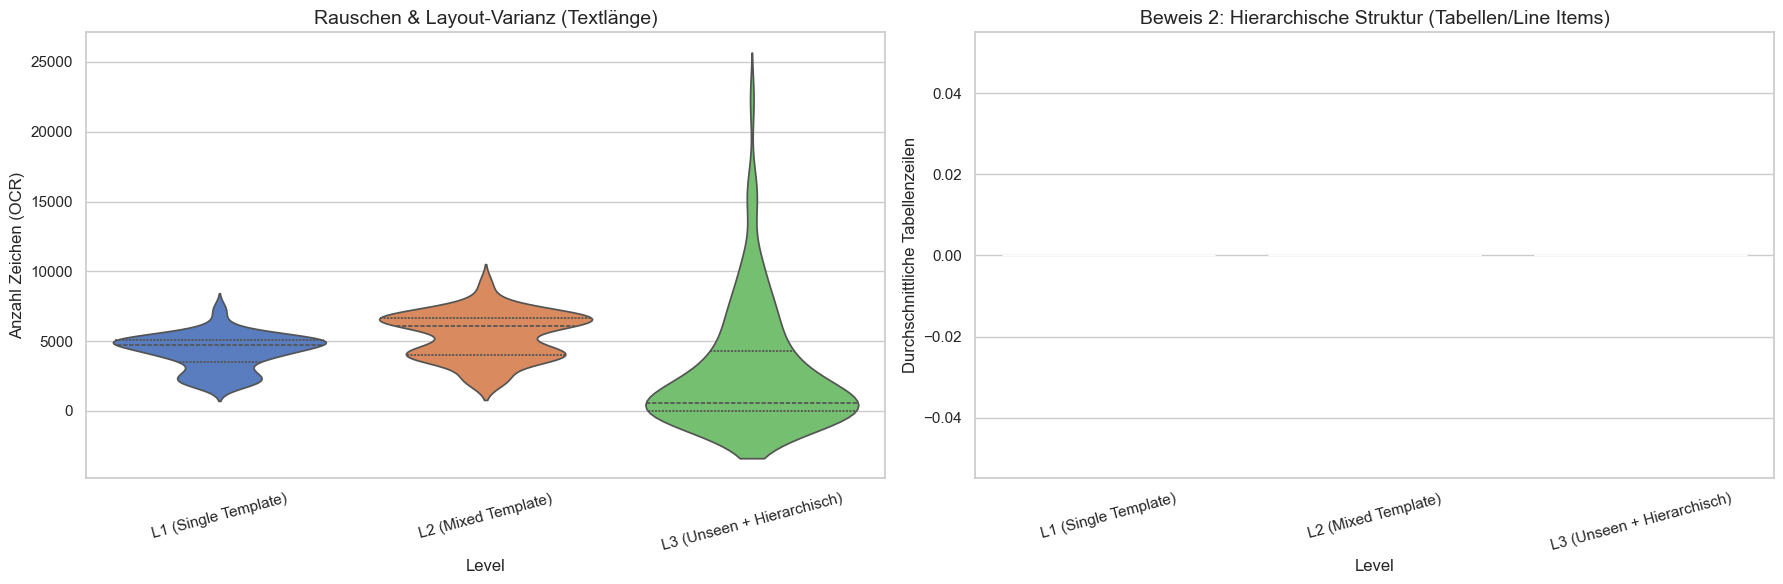

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.violinplot(
    x="Level",
    y="text_length",
    data=df_all,
    ax=axes[0],
    palette="muted",
    inner="quartile",
)
axes[0].set_title("Rauschen & Layout-Varianz (Textlänge)", fontsize=14)
axes[0].set_ylabel("Anzahl Zeichen (OCR)")
axes[0].set_xlabel("Level")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    x="Level",
    y="line_items_count",
    data=df_all,
    ax=axes[1],
    palette="dark",
    errorbar=("ci", 95),
)
axes[1].set_title("Beweis 2: Hierarchische Struktur (Tabellen/Line Items)", fontsize=14)
axes[1].set_ylabel("Durchschnittliche Tabellenzeilen")
axes[1].set_xlabel("Level")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_92760/4152826444.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Level", y="context_per_field", data=df_all, palette="magma")


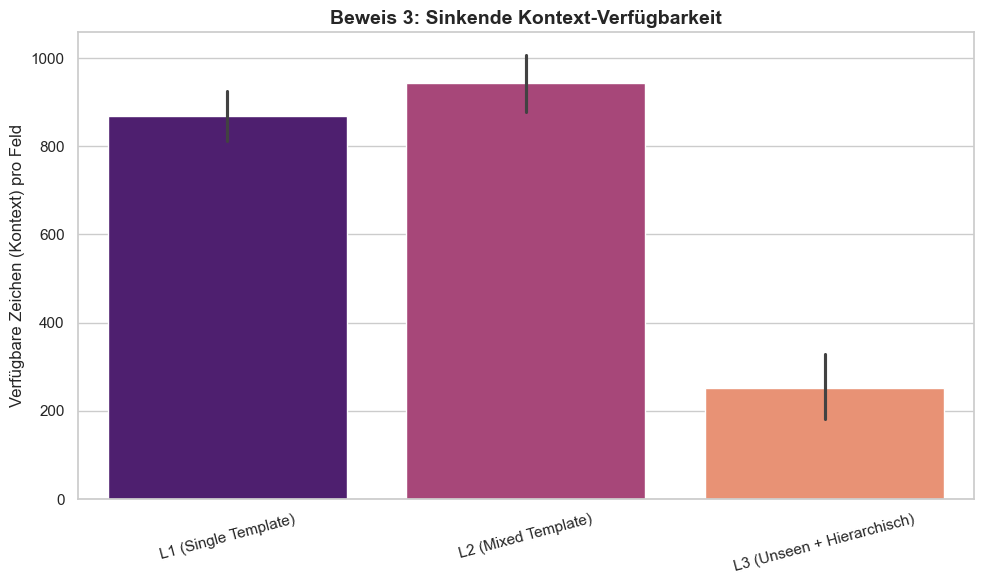

In [115]:
# Wie viele Zeichen Text "erklären" im Schnitt ein Feld?
df_all["context_per_field"] = df_all["text_length"] / (df_all["flat_fields_count"] + 1)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x="Level", y="context_per_field", data=df_all, palette="magma")

ax.set_title("Beweis 3: Sinkende Kontext-Verfügbarkeit", fontsize=14, fontweight="bold")
ax.set_ylabel("Verfügbare Zeichen (Kontext) pro Feld")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

W

1. NLP: Die "Out-of-Vocabulary" (OOV) Rate

In L1 und L2 begegnen dem Modell immer wieder die gleichen Begriffe (z.B. "Rechnungsdatum", "Gesamtbetrag"). In L3 (Unseen) kommen plötzlich Begriffe in anderen Sprachen oder branchenspezifische Abkürzungen vor.

    Die Untersuchung: Wie viele Wörter in L3 kommen in den Trainingsdaten (L1/L2) überhaupt nicht vor?

    Argument: Wenn L3 eine hohe Rate an unbekannten Wörtern hat, versagen klassische Wort-Einbettungen (Word Embeddings). Das Modell muss sich dann auf Zeichenebene oder rein auf das Layout verlassen.

2. CV: Relative 2D-Positionen (Spatial Awareness)

Da in L3 der Textkontext fehlt (dein letzter Plot), muss das Modell die geometrische Beziehung nutzen.

    Die Untersuchung: Berechne die Distanz (in Pixeln) zwischen einem Label (z.B. "Summe") und dem zugehörigen Wert.

    Argument: In L1/L2 sind diese Abstände oft konstant. In L3 variieren sie stark oder das Label fehlt völlig. Du könntest untersuchen, wie weit "Key" und "Value" im 2D-Raum auseinanderliegen. Je größer die Varianz dieser Distanz, desto schwieriger ist die Extraktion für ein Computer-Vision-Modell.

3. Multimodale Interaktion: "Visual Alignment"

Modelle wie LayoutLM kombinieren Text (NLP) und Bild (CV). In L3 kannst du untersuchen, was passiert, wenn die OCR-Boxen leicht verschoben sind.

    Die Untersuchung: "Störe" die Koordinaten deiner OCR-Daten in L3 künstlich (z.B. um 5 Pixel verschieben) und schau, wie die Genauigkeit einbricht.

    Argument: Da L3 kaum Textkontext hat, ist das Modell extrem abhängig von der exakten visuellen Positionierung. In L1 könnte das Modell den Fehler vielleicht noch über den Text ("Ich lese 'Summe', also ist die Zahl daneben der Wert") abfangen. In L3 führt ein kleiner visueller Versatz zum Totalausfall.


    Welches Argument ist am stärksten?

Ich empfehle das Argument der 2D-Spatial-Density. Es verbindet beide Welten:

    NLP: Die semantische Nähe von Wörtern.

    CV: Die physikalische Nähe auf dem Blatt Papier.